# 02 · SFS refinement: validation sweeps and the SHAP noise floor

The SFS stage per backbone: the top-$k$ validation sweep with its variability band, the selected sizes $d_+$ and $d_{pars}$, and the SHAP importance profile against the probe noise floor.

### Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from _shared import (
    BACKBONES,
    BACKBONE_COLORS,
    BACKBONE_LABELS,
    CATEGORY_COLORS,
    DOUBLE_COL,
    N,
    OPERATOR_LABELS,
    PROBE_COLOR,
    feature_category,
    init_notebook,
    jload,
    run_dir,
)

FIG_DIR, savefig = init_notebook("02_sfs_refinement")

campaign: dce-full-rffs-4backbones-xgb-analyses-v2-2026-08-11
figures -> /Users/berthier/Development/PhD/xopa/results/notebook-figures/02_sfs_refinement


In [2]:
curves = {b: pd.read_csv(run_dir(b, "rffs") / "sfs_curve.csv", index_col=0) for b in BACKBONES}
importances = {
    b: pd.read_csv(run_dir(b, "rffs") / "sfs_importance.csv", index_col=0)
    for b in BACKBONES
}
summaries = {b: jload(run_dir(b, "rffs") / "rffs_summary.json") for b in BACKBONES}

## Validation sweep per backbone (mean $\pm$ 3 std over model seeds)

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/02_sfs_refinement/sfs_curves_all_backbones.pdf/.png


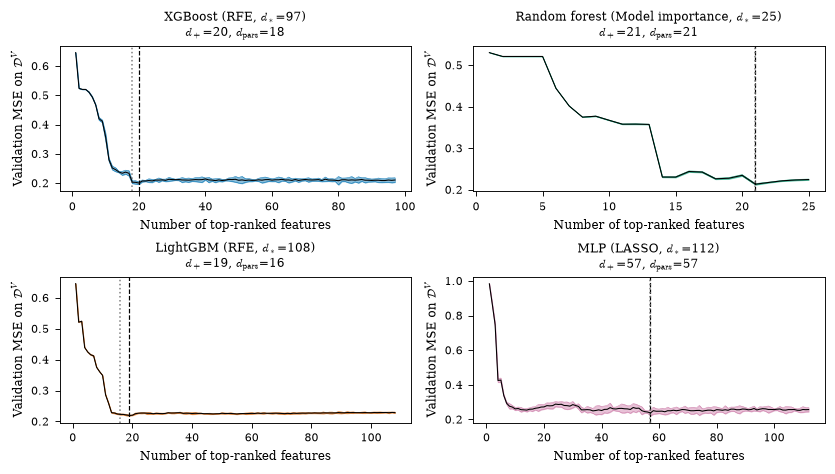

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL, 4.2))
for ax, backbone in zip(axes.ravel(), BACKBONES):
    curve, summary = curves[backbone], summaries[backbone]
    k = curve.index.to_numpy()
    mean, std = curve["mse_mean"].to_numpy(), curve["mse_std"].to_numpy()
    if not np.isfinite(mean).all() or not np.isfinite(std).all():
        raise ValueError(f"{backbone}: non-finite SFS summary values")
    if (std < 0).any():
        raise ValueError(f"{backbone}: negative SFS standard deviation")
    band_width = 3.0 * std
    band_lower = mean - band_width
    band_upper = mean + band_width
    color = BACKBONE_COLORS[backbone]
    ax.fill_between(
        k, band_lower, band_upper, facecolor=color, alpha=0.45,
        edgecolor=color, linewidth=0.45, zorder=1,
    )
    ax.plot(k, band_lower, color=color, lw=0.35, alpha=0.9, zorder=2)
    ax.plot(k, band_upper, color=color, lw=0.35, alpha=0.9, zorder=2)
    ax.plot(k, mean, color="black", lw=0.7, zorder=3)
    ax.axvline(summary["d_plus"], color="black", ls="--", lw=0.8)
    ax.axvline(summary["d_parsimonious"], color="gray", ls=":", lw=1.0)
    winner = summary["winner"]
    grid = pd.read_csv(
        run_dir(backbone, "rffs") / f"grid_eval_{winner['operator']}.csv", index_col=0
    )
    d_star = int(grid.loc[winner["K"], "d_star"])
    ax.set_title(
        f"{BACKBONE_LABELS[backbone]} "
        f"({OPERATOR_LABELS[winner['operator']]}, {N['d_star']}={d_star})\n"
        f"{N['d_plus']}={summary['d_plus']}, $d_{{\\mathrm{{pars}}}}$={summary['d_parsimonious']}"
    )
    ax.set_xlabel("Number of top-ranked features")
    ax.set_ylabel(f"Validation MSE on {N['D_V']}")
savefig(fig, "sfs_curves_all_backbones")
plt.show()

## Refinement gain over the FFS winner (validation MSE)

In [4]:
rows = []
for backbone in BACKBONES:
    summary = summaries[backbone]
    winner = summary["winner"]
    grid = pd.read_csv(
        run_dir(backbone, "rffs") / f"grid_eval_{winner['operator']}.csv", index_col=0
    )
    ffs_mse = round(float(grid.loc[winner["K"], "val_mse"]), 3)
    sfs_mse = round(float(curves[backbone]["mse_mean"].min()), 3)
    d_star = int(grid.loc[winner["K"], "d_star"])
    d_plus = int(summary["d_plus"])
    rows.append(
        {
            "backbone": BACKBONE_LABELS[backbone],
            "FFS winner val MSE (3 d.p.)": ffs_mse,
            f"{N['d_star']}": d_star,
            "SFS best mean val MSE (3 d.p.)": sfs_mse,
            f"{N['d_plus']}": d_plus,
            "MSE change (%)": round(100 * (sfs_mse - ffs_mse) / ffs_mse, 1),
            "dimension change (%)": round(100 * (d_plus - d_star) / d_star, 1),
        }
    )
pd.DataFrame(rows).set_index("backbone")

,FFS winner val MSE (3 d.p.),$d_*$,SFS best mean val MSE (3 d.p.),$d_+$,MSE change (%),dimension change (%)
backbone,,,,,,
XGBoost,0.216,97,0.200,20,-7.4,-79.4
Random forest,0.225,25,0.213,21,-5.3,-16.0
LightGBM,0.228,108,0.219,19,-3.9,-82.4
MLP,0.263,112,0.238,57,-9.5,-49.1


## SHAP importance profiles vs the probe noise floor

Bars: mean $|$SHAP$|$ importance $I_j$ along the complete ranked $d_*$ survivor path (log scale), category-coloured.  
The dotted horizontal line is the larger synthetic-probe importance, and the dashed vertical line marks $d_+$.  
Some unused $d_*$ survivors fall below the probe floor, but every variable in each selected $d_+$ prefix clears it.

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/02_sfs_refinement/sfs_importance_vs_probe_floor.pdf/.png


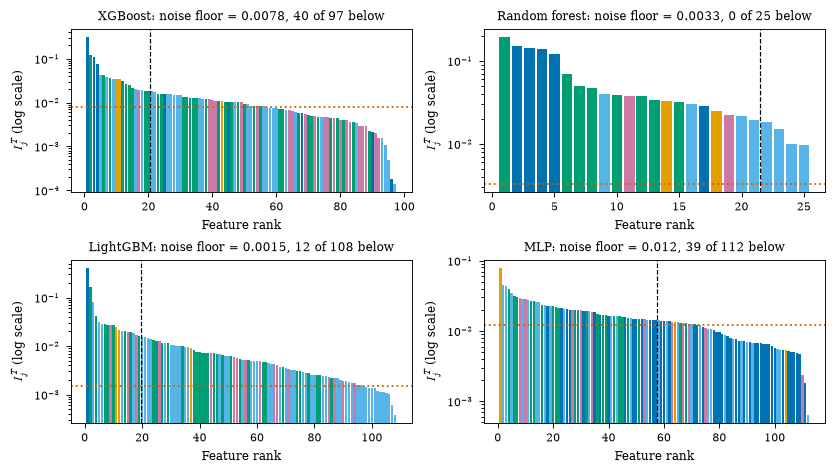

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(DOUBLE_COL, 4.2), sharey=False)
for ax, backbone in zip(axes.ravel(), BACKBONES):
    imp = importances[backbone]
    col = imp.columns[0]
    real = imp[~imp.index.str.startswith("__probe_")].sort_values(col, ascending=False)
    floor = summaries[backbone]["probe_floor"]
    colors = [CATEGORY_COLORS.get(feature_category(f), "#999999") for f in real.index]
    ax.bar(np.arange(1, len(real) + 1), real[col].to_numpy(), color=colors, width=0.85)
    ax.axhline(floor, color=PROBE_COLOR, ls=":", lw=1.2)
    ax.set_yscale("log")
    below = int((real[col] < floor).sum())
    ax.set_title(
        f"{BACKBONE_LABELS[backbone]}: noise floor = {floor:.2g}, {below} of {len(real)} below"
    )
    ax.axvline(summaries[backbone]["d_plus"] + 0.5, color="black", ls="--", lw=0.8)
    ax.set_xlabel("Feature rank")
    ax.set_ylabel(r"$I_j^{T}$ (log scale)")
savefig(fig, "sfs_importance_vs_probe_floor")
plt.show()